In [29]:
from pathlib import Path

DATASET_PATH = "./Sign Language Detection/babeczka"
root = Path(DATASET_PATH)
assert root.exists(), f"Dataset path not found: {DATASET_PATH}. Change DATASET_PATH to correct folder."
print(root)

Sign Language Detection/babeczka


In [30]:
train_images = root / "train" / "images"
train_labels = root / "train" / "labels"

test_images = root / "valid" / "images"
test_labels = root / "valid" / "labels"
print("Train images path:", train_images)
print("Train labels path:", train_labels)

Train images path: Sign Language Detection/babeczka/train/images
Train labels path: Sign Language Detection/babeczka/train/labels


In [31]:
RESIZED_IMG_SIZE=400

In [ ]:
import os
import cv2
import numpy as np

def load_detection_data(img_dir, label_dir, img_size=(RESIZED_IMG_SIZE, RESIZED_IMG_SIZE)):
    images = []
    boxes = [] # Tutaj trafią tylko współrzędne [x, y, w, h]

    file_names = [f for f in os.listdir(label_dir) if f.endswith('.txt')]

    for file_name in file_names:
        # 1. Wczytaj obraz
        img_path = os.path.join(img_dir, file_name.replace('.txt', '.jpg'))
        img = cv2.imread(img_path)
        if img is None: continue
        
        # 2. Wczytaj etykietę (zakładamy format: class x_center y_center w h)
        with open(os.path.join(label_dir, file_name), 'r') as f:
            line = f.readline().split()
            if not line: continue
            
            # Pomijamy klasę (line[0]), bo ten model szuka tylko dłoni ogólnie
            # Dane w pliku są zazwyczaj znormalizowane. Jeśli nie są - podziel przez w_img/h_img
            cx, cy, w, h = map(float, line[1:]) 
            
            # Przeliczamy z center (środek) na top-left (lewy górny róg) - łatwiej się to wycina
            x = cx - (w / 2)
            y = cy - (h / 2)
            
            boxes.append([x, y, w, h])

        # 3. Resize obrazu do formatu wejściowego sieci
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)
        images.append(img / 255.0)

    return np.array(images), np.array(boxes)

# Wczytanie danych
X_train, Y_train = load_detection_data(train_images, train_labels)

X_val, Y_val = load_detection_data(test_images, test_labels)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# def build_locator_model():
#     # 1. Backbone (kręgosłup sieci) - MobileNetV2 bez ostatnich warstw
#     base_model = tf.keras.applications.MobileNetV2(
#         input_shape=(RESIZED_IMG_SIZE, RESIZED_IMG_SIZE, 3),
#         include_top=False, 
#         weights='imagenet'
#     )
#     base_model.trainable = False # Zamrażamy na początek

#     # 2. Head (głowa sieci) - nasza własna część regresyjna
#     x = layers.Flatten()(base_model.output)
#     x = layers.Dense(128, activation='relu')(x)
#     x = layers.Dropout(0.3)(x) # Zapobiega overfittingowi
#     x = layers.Dense(64, activation='relu')(x)
    
#     # Wyjście: 4 wartości [x, y, w, h]
#     # Sigmoid wymusza wynik w zakresie 0-1
#     outputs = layers.Dense(4, activation='sigmoid')(x)

#     model = models.Model(inputs=base_model.input, outputs=outputs)
#     return model

# detector = build_locator_model()

# def build_locator_model(img_size):
#     inputs = layers.Input(shape=(img_size, img_size, 3))
    
#     # 1. Konwolucje (Ekstrakcja cech)
#     x = layers.Conv2D(16, 3, padding='same', activation='relu')(inputs)
#     x = layers.MaxPooling2D()(x)
    
#     x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
#     x = layers.MaxPooling2D()(x)
    
#     x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
#     x = layers.MaxPooling2D()(x)

#     x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
#     x = layers.MaxPooling2D()(x)
    
#     # 2. Głowa Regresji (Localization Head)
#     # KLUCZOWE: Flatten zamiast GlobalAveragePooling
#     x = layers.Flatten()(x)
    
#     x = layers.Dense(128, activation='relu')(x)
#     x = layers.Dropout(0.2)(x) # Zapobiega przeuczeniu
    
#     # 3. Wyjście
#     # 4 neurony: [x, y, w, h]
#     # Aktywacja 'sigmoid', bo wartości muszą być między 0 a 1
#     outputs = layers.Dense(4, activation='sigmoid')(x)
    
#     model = models.Model(inputs, outputs)
#     return model

# # Kompilacja
# detector = build_locator_model(RESIZED_IMG_SIZE)


import tensorflow as tf
from tensorflow.keras import layers, models

def build_locator_model():
    # 1. Backbone (MobileNetV2)
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(RESIZED_IMG_SIZE, RESIZED_IMG_SIZE, 3),
        include_top=False, 
        weights='imagenet'
    )
    
    # Zamrażamy bazę na start
    # UWAGA: Później, w 2. fazie treningu, warto odmrozić ostatnie 20 warstw!
    base_model.trainable = False 

    # 2. Head (Głowa regresyjna)
    x = base_model.output
    
    # Flatten - zachowuje informację przestrzenną
    x = layers.Flatten()(x)
    
    # --- Blok Dense 1 ---
    x = layers.Dense(256)(x)                 # Zwiększamy pojemność do 256 neuronów
    x = layers.BatchNormalization()(x)       # STABILIZACJA (Kluczowe dla regresji!)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)               # Agresywny dropout (MobileNet produkuje dużo cech)

    # --- Blok Dense 2 ---
    x = layers.Dense(64)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)
    
    # --- Wyjście ---
    # 4 wartości: [x, y, w, h] (znormalizowane 0-1)
    outputs = layers.Dense(4, activation='sigmoid')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)
    return model

# Budowa modelu
detector = build_locator_model()

/tmp/ipykernel_18672/906163833.py:68: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [34]:
# Kompilacja
detector.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',      # Minimalizujemy błąd odległości
    metrics=['mae', 'accuracy']  # Średni błąd bezwzględny (dla czytelności)
)

# Callbacks - przydatne narzędzia
callbacks = [
    # Zapisz model tylko, gdy wynik na walidacji się poprawi
    tf.keras.callbacks.ModelCheckpoint(
        'hand_detector_best.keras', 
        save_best_only=True, 
        monitor='val_loss'
    ),
    # Zmniejsz learning rate, gdy sieć przestanie się uczyć
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=3
    ),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
]

# Start treningu
history = detector.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=50,       # Regresja wymaga zazwyczaj więcej epok niż klasyfikacja
    batch_size=16,
    callbacks=callbacks
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.3783 - loss: 0.0728 - mae: 0.2183 - val_accuracy: 0.6053 - val_loss: 0.1472 - val_mae: 0.3283 - learning_rate: 0.0010
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 313ms/step - accuracy: 0.4652 - loss: 0.0513 - mae: 0.1809 - val_accuracy: 0.6053 - val_loss: 0.0721 - val_mae: 0.2201 - learning_rate: 0.0010
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 327ms/step - accuracy: 0.5043 - loss: 0.0373 - mae: 0.1508 - val_accuracy: 0.6711 - val_loss: 0.0448 - val_mae: 0.1726 - learning_rate: 0.0010
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 327ms/step - accuracy: 0.5522 - loss: 0.0308 - mae: 0.1402 - val_accuracy: 0.6974 - val_loss: 0.0284 - val_mae: 0.1342 - learning_rate: 0.0010
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 337ms/step - accuracy: 0.5565 - loss: 0.0279 - mae: 0.1318 - val_accuracy: 0.7632 - val_loss: 0.0191 - val_mae: 0.1117 - learning_rate: 0.0010
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 351ms/step - accuracy: 0.5913 - loss: 0.0

In [35]:
score = detector.evaluate(X_val, Y_val)

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.8816 - loss: 0.0012 - mae: 0.0267


In [36]:
def crop_hand(image_path, model):
    # 1. Przygotuj obraz
    original_img = cv2.imread(image_path)
    img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (RESIZED_IMG_SIZE, RESIZED_IMG_SIZE)) / 255.0
    input_tensor = np.expand_dims(img_resized, axis=0)

    # 2. Predykcja ramki
    box = model.predict(input_tensor)[0] # [x, y, w, h] (znormalizowane)
    
    # 3. Przelicz na piksele
    h_orig, w_orig, _ = original_img.shape
    x = int(box[0] * w_orig)
    y = int(box[1] * h_orig)
    w = int(box[2] * w_orig)
    h = int(box[3] * h_orig)

    # Zabezpieczenia (żeby nie wyjść poza obraz przy błędzie modelu)
    x = max(0, x)
    y = max(0, y)
    
    # 4. Wycięcie (Crop)
    # Dodajemy mały margines (padding), żeby nie uciąć palców
    padding = 20
    crop = original_img[y-padding : y+h+padding, x-padding : x+w+padding]
    
    return crop, (x, y, w, h)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


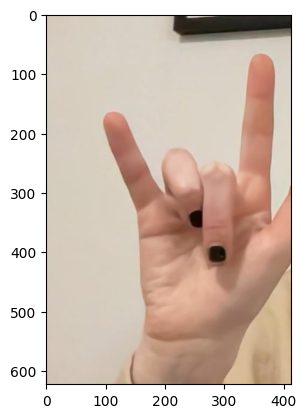

In [37]:
# Test

import matplotlib.pyplot as plt

cropped_img, coords = crop_hand("./Sign Language Detection/babeczka/test/images/iloveyou_1f4c00c4-7679-11ed-bb1e-1e08bc6ed8a6_jpg.rf.e6b72a4127ff5544f3bd78317ca11b0e.jpg", detector)

if cropped_img.size > 0:
    cropped_img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)
    plt.imshow(cropped_img_rgb)

In [38]:
# import os

# LABELS_DIR = "./Sign Language Detection/babeczka/valid/labels"
# IMAGES_DIR = "./Sign Language Detection/babeczka/valid/images"

# for filename in os.listdir(LABELS_DIR):
#     if not filename.endswith(".txt"):
#         continue

#     label_path = os.path.join(LABELS_DIR, filename)

#     # Check if label file is empty or only whitespace
#     with open(label_path, "r") as f:
#         content = f.read().strip()

#     if content == "":
#         image_name = os.path.splitext(filename)[0] + ".jpg"
#         image_path = os.path.join(IMAGES_DIR, image_name)

#         if os.path.exists(image_path):
#             os.remove(image_path)
#             print(f"Deleted image: {image_path}")
#         else:
#             print(f"Image not found: {image_path}")

#         # OPTIONAL: delete the empty label file itself
#         os.remove(label_path)
#         print(f"Deleted label: {label_path}")


In [39]:
# import os
# from pathlib import Path

# # --- KONFIGURACJA ---
# # Ustaw ścieżki do folderów
# # BASE_DIR = Path('.') # Zakładamy, że skrypt jest obok folderu 'train'
# LABEL_DIR = root / "valid" / "labels"
# IMAGE_DIR = root / "valid" / "images"

# # Klasa do usunięcia (jako string, bo czytamy z pliku tekstowego)
# TARGET_CLASS = '3' 

# def clean_dataset():
#     if not LABEL_DIR.exists() or not IMAGE_DIR.exists():
#         print(f"BŁĄD: Nie znaleziono folderów:\n{LABEL_DIR}\n{IMAGE_DIR}")
#         print("Upewnij się, że uruchamiasz skrypt w dobrym miejscu.")
#         return

#     print(f"Szukanie plików z klasą '{TARGET_CLASS}' w: {LABEL_DIR}...")
    
#     deleted_count = 0
#     errors_count = 0

#     # Pobieramy wszystkie pliki .txt
#     label_files = list(LABEL_DIR.glob('*.txt'))

#     for label_path in label_files:
#         should_delete = False
        
#         try:
#             with open(label_path, 'r') as f:
#                 lines = f.readlines()
                
#             # Sprawdzamy każdą linię w pliku
#             for line in lines:
#                 parts = line.strip().split()
#                 # Format YOLO: <class_id> <x> <y> <w> <h>
#                 # Sprawdzamy pierwszy element (class_id)
#                 if parts and parts[0] == TARGET_CLASS:
#                     should_delete = True
#                     break
            
#             if should_delete:
#                 # 1. Usuwamy plik etykiety (.txt)
#                 os.remove(label_path)
                
#                 # 2. Szukamy i usuwamy odpowiadający obraz
#                 # Obraz ma tę samą nazwę (stem), ale inne rozszerzenie (.jpg, .png, .JPG itp.)
#                 file_stem = label_path.stem
                
#                 # Szukamy dowolnego pliku w folderze images, który ma tę samą nazwę
#                 found_image = False
#                 for img_path in IMAGE_DIR.glob(f"{file_stem}.*"):
#                     os.remove(img_path)
#                     found_image = True
#                     print(f"[USUNIĘTO] Label: {label_path.name} | Obraz: {img_path.name}")
                
#                 if not found_image:
#                     print(f"[USUNIĘTO] Label: {label_path.name} (Obrazu nie znaleziono)")
                
#                 deleted_count += 1

#         except Exception as e:
#             print(f"[BŁĄD] Nie można przetworzyć pliku {label_path}: {e}")
#             errors_count += 1

#     print("-" * 30)
#     print(f"Zakończono.")
#     print(f"Usunięto par plików: {deleted_count}")
#     if errors_count > 0:
#         print(f"Błędy: {errors_count}")

# clean_dataset()

In [40]:
# import os
# from pathlib import Path

# LABEL_DIR = root / "train" / "labels"

# OLD_CLASS = '4'  # Co zmieniamy
# NEW_CLASS = '3'  # Na co zmieniamy

# def reindex_labels():
#     if not LABEL_DIR.exists():
#         print(f"BŁĄD: Nie znaleziono folderu: {LABEL_DIR}")
#         return

#     print(f"Rozpoczynam zamianę klasy {OLD_CLASS} -> {NEW_CLASS} w folderze: {LABEL_DIR}...")
    
#     modified_files_count = 0
#     total_lines_changed = 0

#     # Pobieramy wszystkie pliki .txt
#     label_files = list(LABEL_DIR.glob('*.txt'))

#     for label_path in label_files:
#         file_modified = False
#         new_lines = []

#         try:
#             # 1. Odczyt pliku
#             with open(label_path, 'r') as f:
#                 lines = f.readlines()

#             # 2. Przetwarzanie linia po linii
#             for line in lines:
#                 parts = line.strip().split()
                
#                 # Jeśli linia nie jest pusta
#                 if parts:
#                     # Sprawdzamy czy pierwsza liczba (class_id) to nasza "4"
#                     if parts[0] == OLD_CLASS:
#                         parts[0] = NEW_CLASS
#                         file_modified = True
#                         total_lines_changed += 1
                    
#                     # Odtwarzamy linię (łączymy spacjami i dodajemy znak nowej linii)
#                     new_line = " ".join(parts) + "\n"
#                     new_lines.append(new_line)
#                 else:
#                     # Zachowujemy puste linie jeśli były
#                     new_lines.append("\n")

#             # 3. Zapis zmian (tylko jeśli coś się zmieniło)
#             if file_modified:
#                 with open(label_path, 'w') as f:
#                     f.writelines(new_lines)
#                 modified_files_count += 1
#                 print(f"[ZMIANA] Zaktualizowano plik: {label_path.name}")

#         except Exception as e:
#             print(f"[BŁĄD] Problem z plikiem {label_path.name}: {e}")

#     print("-" * 30)
#     print("Zakończono.")
#     print(f"Zmodyfikowano plików: {modified_files_count}")
#     print(f"Łącznie zmienionych etykiet: {total_lines_changed}")


# reindex_labels()